# Анализ данных бразильского маркетплейса Olist

**Цель:** выявить ключевые проблемы бизнеса — почему клиенты недовольны, где теряется выручка и как сегментировать клиентов.

**Данные:** реальные данные Olist за 2016–2018 гг. (~100к заказов, 9 таблиц)  
**Источник:** [Kaggle — Brazilian E-Commerce Public Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
**Стек:** Python, pandas, SQLAlchemy, PostgreSQL, seaborn, matplotlib

## Блок 1. Загрузка данных в PostgreSQL

Подключаемся к локальной базе данных и загружаем все CSV файлы как отдельные таблицы.

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine


engine = create_engine('postgresql://max_power@localhost:5432/olist')
print('Connected!')

Connected!


In [45]:
import os 

path = '/Users/max_power/Projects/olist_data/'
csv_files = [f for f in os.listdir(path) if f.endswith('csv')]
print(csv_files)

['olist_sellers_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv']


In [46]:
for file in csv_files:
    table_name = file.replace('.csv', '')
    df = pd.read_csv(path + file)
    df.to_sql(table_name, engine, if_exists='replace', index=False)
    print(f'Загружено: {table_name} - {df.shape[0]} строк')

Загружено: olist_sellers_dataset - 3095 строк
Загружено: product_category_name_translation - 71 строк
Загружено: olist_orders_dataset - 99441 строк
Загружено: olist_order_items_dataset - 112650 строк
Загружено: olist_customers_dataset - 99441 строк
Загружено: olist_geolocation_dataset - 1000163 строк
Загружено: olist_order_payments_dataset - 103886 строк
Загружено: olist_order_reviews_dataset - 99224 строк
Загружено: olist_products_dataset - 32951 строк


## Блок 2. Динамика продаж

Смотрим как менялась выручка по месяцам за весь период.  
Используем SQL запрос с `DATE_TRUNC` для группировки по месяцам и `JOIN` таблиц заказов и позиций.

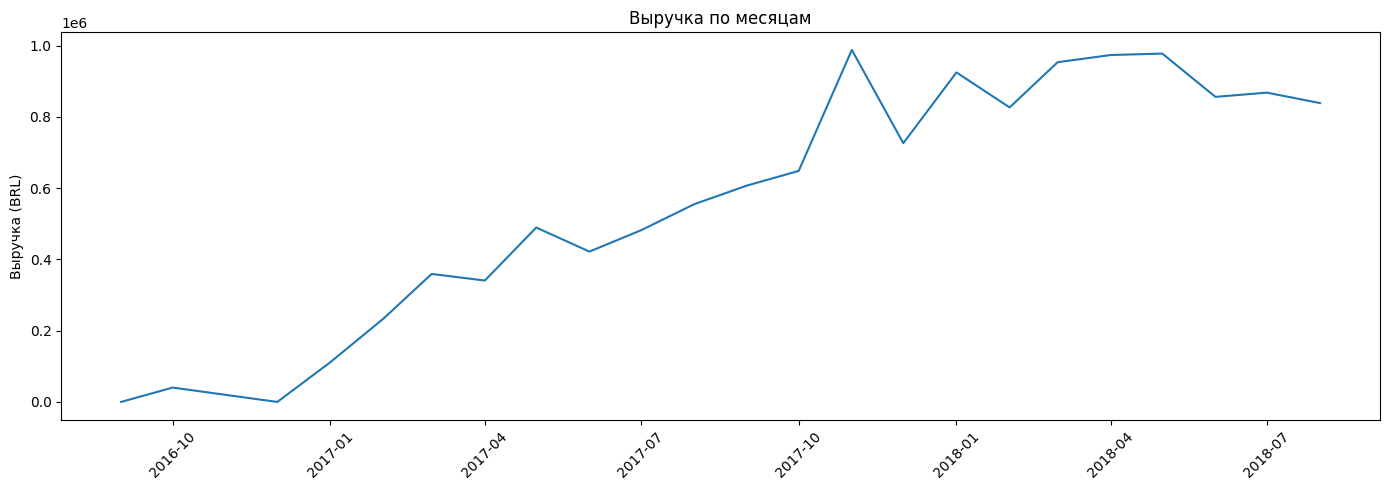

In [47]:
query = '''
SELECT 
	DATE_TRUNC('month', ood.order_purchase_timestamp::timestamp) AS month,
	round(sum(ooi.price)::NUMERIC ,2) AS total_revenue
FROM olist_orders_dataset ood 
JOIN olist_order_items_dataset ooi ON ood.order_id = ooi.order_id 
WHERE order_status = 'delivered'
GROUP BY DATE_TRUNC('month', ood.order_purchase_timestamp::timestamp)
ORDER BY month;'''
df_revenue = pd.read_sql(query, engine)

plt.figure(figsize=(14, 5))
sns.lineplot(data=df_revenue, x='month', y='total_revenue')
plt.title('Выручка по месяцам')
plt.xlabel('')
plt.ylabel('Выручка (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Вывод:** выручка стабильно росла на протяжении всего периода.  
Заметный пик в **ноябре 2017** — совпадает с Black Friday.  
Январь традиционно сильный месяц для Бразилии — разгар южного лета.

## Блок 3. Топ категории по выручке

Определяем какие категории товаров приносят наибольшую выручку.  
Джойним три таблицы: товары, позиции заказов и переводы категорий на английский.

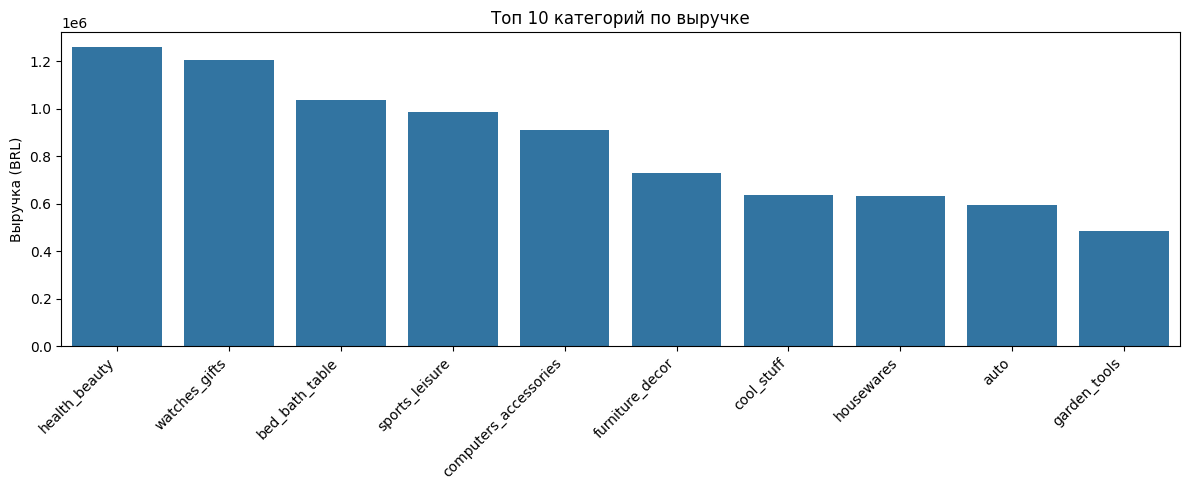

In [48]:
query = '''
SELECT 
	pcnt.product_category_name_english,
    round(sum(ooid.price)::NUMERIC, 2) AS total_revenue
FROM olist_products_dataset opd
JOIN olist_order_items_dataset ooid ON opd.product_id = ooid.product_id
JOIN product_category_name_translation pcnt ON opd.product_category_name = pcnt.product_category_name
GROUP BY pcnt.product_category_name_english
ORDER BY total_revenue DESC 
LIMIT 10;
'''
df_categories = pd.read_sql(query, engine)

plt.figure(figsize=(12, 5))
sns.barplot(data=df_categories, x='product_category_name_english', y='total_revenue')
plt.title('Топ 10 категорий по выручке')
plt.xlabel('')
plt.ylabel('Выручка (BRL)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Вывод:** лидер по выручке — **health_beauty**, за ней **watches_gifts** и **bed_bath_table**.  
Эти категории — ключевые драйверы выручки платформы.

## Блок 4. Анализ доставки по штатам

Считаем среднее время доставки для каждого штата — от даты покупки до даты получения.

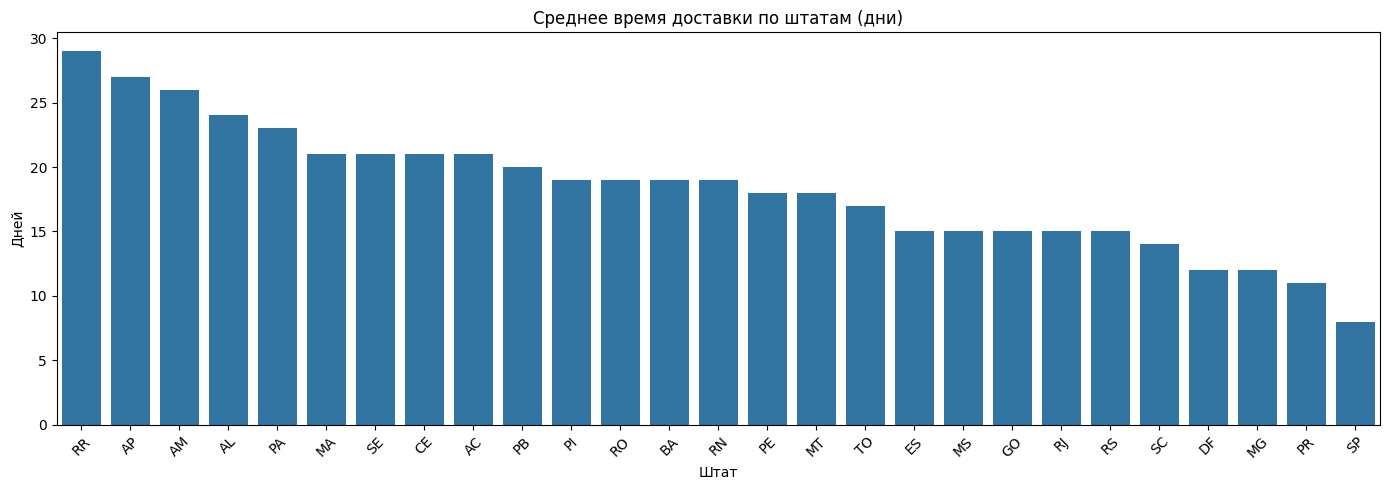

In [49]:
query = '''
SELECT
	ocd.customer_state AS state,
	avg(ood.order_delivered_customer_date::timestamp - ood.order_purchase_timestamp::timestamp) AS delivery_time
FROM olist_customers_dataset ocd
JOIN olist_orders_dataset ood ON ocd.customer_id = ood.customer_id
WHERE ood.order_status = 'delivered'
GROUP BY ocd.customer_state
ORDER BY delivery_time DESC;
'''
df_avg_delivery_time = pd.read_sql(query, engine)
df_avg_delivery_time['delivery_days'] = df_avg_delivery_time['delivery_time'].dt.days

plt.figure(figsize=(14, 5))
sns.barplot(data=df_avg_delivery_time, x='state', y='delivery_days')
plt.title('Среднее время доставки по штатам (дни)')
plt.xlabel('Штат')
plt.ylabel('Дней')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Вывод:** самая долгая доставка в северных штатах — **RR (Roraima), AP (Amapá), AM (Amazonas)**.  
Это труднодоступные регионы с плохой логистической инфраструктурой и джунглями.

## Блок 5. Влияние опозданий на оценку клиентов

Проверяем гипотезу: опоздание доставки негативно влияет на оценку клиента.  
Используем `CASE WHEN` для разделения заказов на опоздавшие и вовремя доставленные.

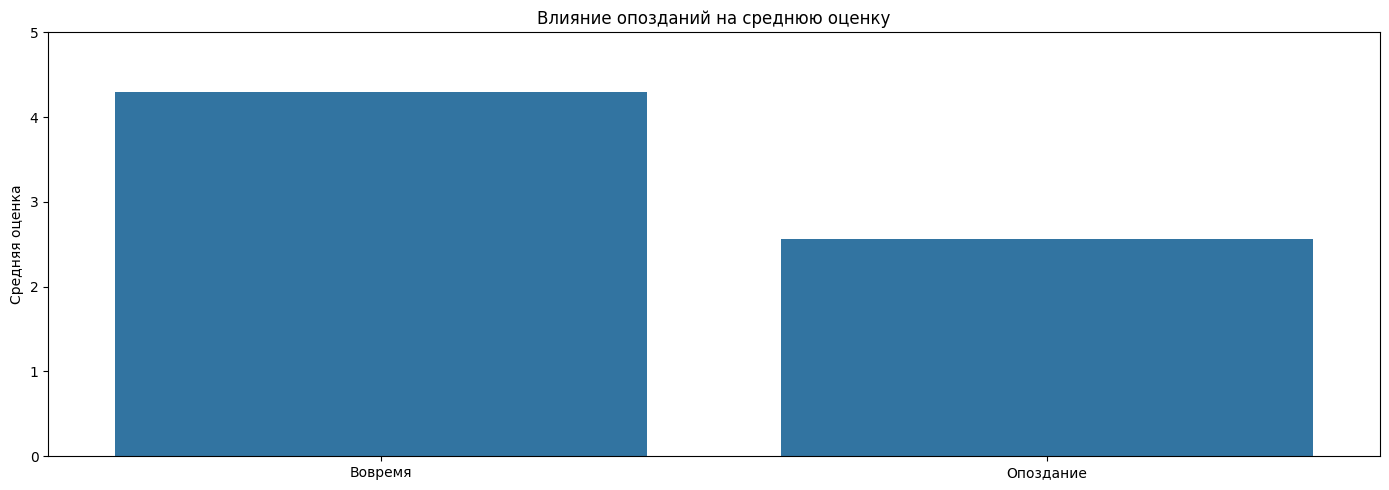

In [53]:
query = '''
SELECT 
	avg(oord.review_score) AS score,
	CASE 
		WHEN ood.order_delivered_customer_date::timestamp > ood.order_estimated_delivery_date::timestamp THEN 'Опоздание'
		ELSE 'Вовремя'
	END AS is_late
FROM olist_orders_dataset ood 
JOIN olist_order_reviews_dataset oord ON ood.order_id = oord.order_id
WHERE ood.order_status = 'delivered'
GROUP BY is_late;
'''
df_scores = pd.read_sql(query, engine)

plt.figure(figsize=(14, 5))
sns.barplot(data=df_scores, x='is_late', y='score')
plt.title('Влияние опозданий на среднюю оценку')
plt.xlabel('')
plt.ylabel('Средняя оценка')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

**Вывод:** опоздание роняет среднюю оценку с **4.2 до 2.5** — почти в два раза.  
Это прямое доказательство что улучшение логистики напрямую повысит удовлетворенность клиентов.

## Блок 6. RFM сегментация клиентов

**RFM** — классический метод сегментации клиентов по трем метрикам:
- **R (Recency)** — сколько дней назад была последняя покупка
- **F (Frequency)** — сколько раз покупал
- **M (Monetary)** — на какую сумму купил суммарно

Используем CTE и оконную функцию `NTILE(3)` для разделения клиентов на 3 группы по каждой метрике.

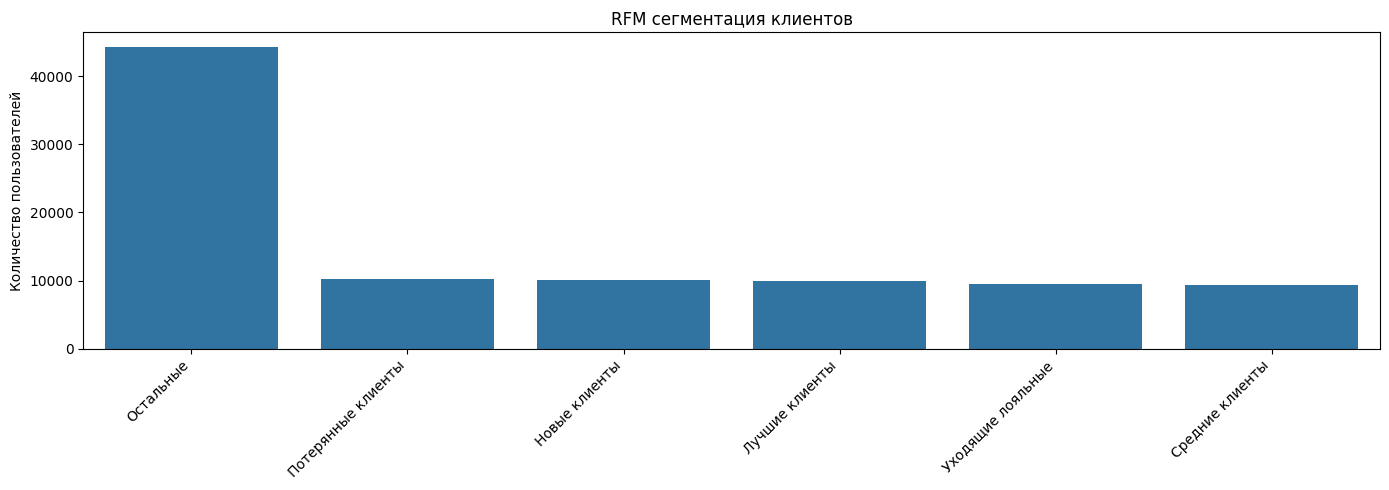

In [58]:
query = '''
WITH rfm_base AS (
	SELECT 
		ocd.customer_unique_id,
		date_part('day', '2018-10-01'::timestamp - max(ood.order_purchase_timestamp::timestamp)) AS recency,
		count(DISTINCT ood.order_id) AS frequency,
		round(sum(ooid.price)::NUMERIC) AS monetary
	FROM olist_customers_dataset ocd
	JOIN olist_orders_dataset ood ON ocd.customer_id = ood.customer_id
	JOIN olist_order_items_dataset ooid ON ood.order_id = ooid.order_id
	WHERE ood.order_status = 'delivered'
	GROUP BY ocd.customer_unique_id
),
rfm_scores AS (
	SELECT 
		customer_unique_id,
		recency,
		frequency,
		monetary,
		ntile(3) OVER (ORDER BY recency desc) AS r_score,
		ntile(3) OVER (ORDER BY frequency asc) AS f_score,
		ntile(3) OVER (ORDER BY monetary asc) AS m_score
	FROM rfm_base
	),
rfm_segments AS (
	SELECT 
		customer_unique_id,
		recency,
		frequency,
		monetary,
		r_score,
		f_score,
		m_score,
		CASE 
			WHEN r_score = 3 AND f_score = 3 AND m_score = 3 THEN 'Лучшие клиенты'
			WHEN r_score = 3 AND f_score = 1 AND m_score = 1 THEN 'Новые клиенты'
			WHEN r_score = 1 AND f_score = 3 AND m_score = 3 THEN 'Уходящие лояльные'
			WHEN r_score = 1 AND f_score = 1 AND m_score = 1 THEN 'Потерянные клиенты'
			WHEN r_score = 2 AND f_score = 2 AND m_score = 2 THEN 'Средние клиенты'
			ELSE 'Остальные'
		END AS segment
	FROM rfm_scores
)
SELECT segment, COUNT(*) AS customers
FROM rfm_segments
GROUP BY segment
ORDER BY customers DESC;
'''
df_rfm = pd.read_sql(query, engine)

plt.figure(figsize=(14, 5))
sns.barplot(data=df_rfm, x='segment', y='customers')
plt.title('RFM сегментация клиентов')
plt.xlabel('')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Вывод:** сегменты распределены равномерно (~10к каждый).  
**Потерянных клиентов** чуть больше чем Лучших — сигнал для работы над удержанием.  
**Уходящие лояльные** (9.5к) — клиенты которые раньше покупали много но давно не возвращались, приоритет для реактивации.

## Блок 7. Retention Rate

Считаем долю клиентов которые сделали повторную покупку.

In [73]:
query = '''
SELECT 
	frequency,
	count(*) AS number_of_customers
FROM (
	SELECT
		ocd.customer_unique_id,
		count(DISTINCT ood.order_id) AS frequency
	FROM olist_customers_dataset ocd
	JOIN olist_orders_dataset ood ON ocd.customer_id = ood.customer_id
	WHERE ood.order_status = 'delivered'
	GROUP BY ocd.customer_unique_id
	) t 
GROUP BY frequency
ORDER BY frequency;
'''
df_retention = pd.read_sql(query, engine)

total = df_retention['number_of_customers'].sum()
returned = df_retention[df_retention['frequency'] > 1]['number_of_customers'].sum()
retention_rate = round(returned / total * 100, 2)

print(f'Всего клиентов: {total}')
print(f'Вернулись: {returned}')
print(f'Retention Rate: {retention_rate}%')

Всего клиентов: 93358
Вернулись: 2801
Retention Rate: 3.0%


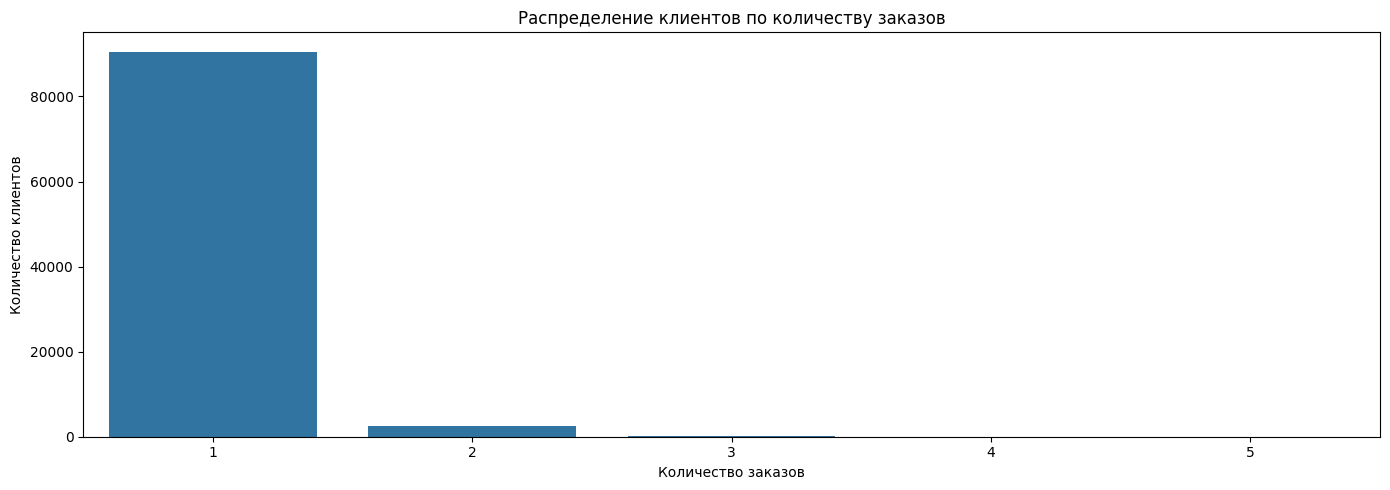

In [75]:
plt.figure(figsize=(14, 5))
sns.barplot(data=df_retention[df_retention['frequency'] <= 5], x='frequency', y='number_of_customers')
plt.title('Распределение клиентов по количеству заказов')
plt.xlabel('Количество заказов')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

**Вывод:** Retention Rate всего **3%** — критически низкий показатель.  
Норма для e-commerce 20-30%. Почти все клиенты (97%) делают одну покупку и уходят.  
Это главная проблема бизнеса — платформа хорошо привлекает новых клиентов но не удерживает их.

## Блок 8. Анализ продавцов

Смотрим топ продавцов по выручке и худших по оценкам (минимум 30 заказов).

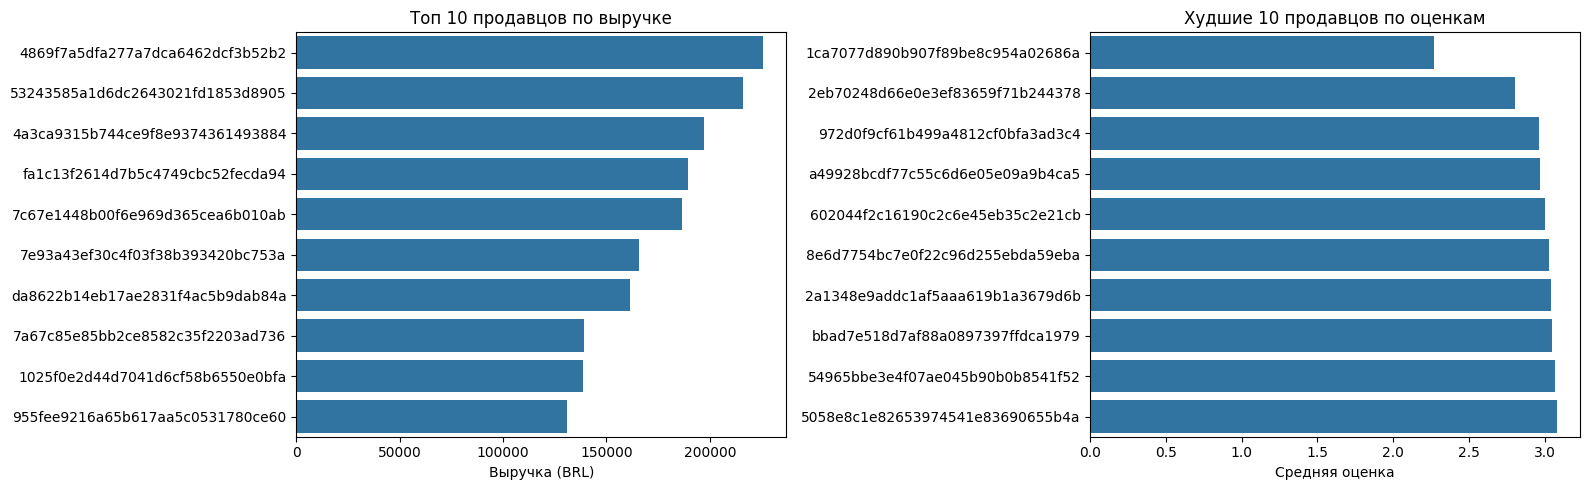

In [77]:
query = '''
SELECT
	osd.seller_id,
	sum(ooid.price) AS total_revenue,
	count(DISTINCT ooid.order_id) AS number_of_orders,
	avg(oord.review_score) AS avg_score
FROM olist_sellers_dataset osd
JOIN olist_order_items_dataset ooid ON osd.seller_id = ooid.seller_id
JOIN olist_orders_dataset ood ON ooid.order_id = ood.order_id
JOIN olist_order_reviews_dataset oord ON ood.order_id = oord.order_id
WHERE ood.order_status = 'delivered'
GROUP BY osd.seller_id
HAVING count(DISTINCT ooid.order_id) >= 30
ORDER BY number_of_orders DESC;
'''
df_sellers = pd.read_sql(query, engine)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top10_profit = df_sellers.nlargest(10, 'total_revenue')
sns.barplot(data=top10_profit, x='total_revenue', y='seller_id', ax=axes[0])
axes[0].set_title('Топ 10 продавцов по выручке')
axes[0].set_xlabel('Выручка (BRL)')
axes[0].set_ylabel('')

worst10_score = df_sellers.nsmallest(10, 'avg_score')
sns.barplot(data=worst10_score, x='avg_score', y='seller_id', ax=axes[1])
axes[1].set_title('Худшие 10 продавцов по оценкам')
axes[1].set_xlabel('Средняя оценка')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Вывод:** среди продавцов с 30+ заказами есть те у кого средняя оценка ниже 2.5 при большом объеме заказов.  
Это сигнал для платформы — такие продавцы портят репутацию и требуют внимания.

## Итоговые выводы и рекомендации

### Главные инсайты:
1. **Рост бизнеса** — выручка стабильно росла в 2016–2018, пик в ноябре 2017 (Black Friday)
2. **Логистические проблемы** — штаты RR, AP, AM показывают наибольшее время доставки
3. **Опоздание = плохой отзыв** — оценка падает с 4.2 до 2.5 при опоздании
4. **Retention 3%** — главная проблема, почти все клиенты не возвращаются
5. **Топ категория** — health_beauty приносит больше всего выручки
6. **Проблемные продавцы** — ряд продавцов с большим объемом заказов имеют низкий рейтинг

### Рекомендации:
- Улучшить логистику в северных штатах RR, AP, AM
- Ввести программу лояльности для повышения Retention
- Реактивировать сегмент "Уходящие лояльные" через персональные предложения
- Ввести систему предупреждений для продавцов с оценкой ниже 3.0
- Инвестировать в развитие категории health_beauty как ключевого драйвера выручки